# **Tech Challenge - 13DTA - Grupo 14**


In [ ]:
#Carreagndo as Bibliotecas Utilizadas
#Panda/numpy/seaborn/matplotlib/plotly

# Faz a manipulação dos dados
import pandas as pd
import numpy as np

# Faz a visualização dos dados
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


## **1. Objetivos do Projeto**
</br>
</br>

O desafio principal consiste na construção de um relatório executivo direcionado a investidores e acionistas do setor de e-commerce com base nos dados púclicos do Brazilian E-Commerce Public Dataset by Olist

</br>  

**Os objetivos específicos incluem:**
</br>

**Transformação de Dados:**
Converter dados transacionais do Brazilian E-Commerce Public Dataset by Olist em uma narrativa clara sobre desempenho comercial, eficiência logística e/ou satisfação do cliente
</br>

**Geração de Insights:**
Fornecer recomendações acionáveis e, se possível, previsões fundamentadas com base na análise
</br>

**Análise Multidimensional:**
Explorar trilhas analíticas como crescimento e receita, logística (SLA), comportamento de pagamento e satisfação do cliente (NPS)
</br>

**Comunicação Executiva:** Utilizar técnicas de storytelling para conectar os dados às decisões de investimento, utilizando uma linguagem acessível a diretores (sem termos técnicos)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **2. Entregas Obrigatórias**

Para a conclusão da atividade, iremos fornecer os seguintes itens:

**2.1. Link do Repositório no GitHub:** Contendo todos os códigos utilizados para o processamento e análise dos dados

**2.2. Link da Apresentação Executiva:** Material visual que suporte a narrativa e o storytelling desenvolvido

**2.3. Vídeo Executivo:** Duração máxima de 5 minutos, apresentado por pelo menos um integrante do grupo, focado em resultados e recomendações, utilizando linguagem executiva.

**2.4. Relatório Executivo Estruturado:** Documento contendo sumário, contexto, análise e conclusões

## **3. Descobrindo o Problema**
</br>

### **3.1. Análise das bases de dados**
</br>

Abaixo estão os principais pontos de conexão para relacionar os dados:
</br>
</br>


**Clientes / Pedidos**</br>
</br>
**order_id**
</br>

É a principal coluna para o fluxo de pedidos.
Ela conecta as tabelas de pedidos (orders), itens (order_items), pagamentos (order_payments) e avaliações (order_reviews).

</br>
</br>

**customer_id**
</br>

Conecta a tabela de clientes (customers) com a de pedidos (orders).
`Existe também o customer_unique_id na base de clientes, que serve para identificar o mesmo cliente em diferentes compras.`

</br>
</br>

**product_id**</br>
Conecta os itens do pedido (order_items) com a base de detalhes dos produtos (products).

</br>
</br>

**seller_id**</br>
Relaciona os vendedores (sellers) com os itens que foram vendidos em cada pedido (order_items).
</br>
</br>

**product_category_name**</br>
Serve para traduzir as categorias de português para inglês usando o arquivo product_category_name_translation.
</br>
</br>
</br>
**Geolocalização (ZIP Code)**</br>
customer_zip_code_prefix (em Clientes) ↔ geolocation_zip_code_prefix (em Geolocation).

</br>
seller_zip_code_prefix (em Vendedores) ↔ geolocation_zip_code_prefix (em Geolocation).

</br>
</br>
</br>

**Mapper**</br>

De (Tabela)   Para (Tabela)   Coluna de Ligação</br>
orders        order_items     order_id</br>
orders        customers       customer_id</br>
order_items   products        product_id</br>
order_items   sellers         seller_id</br>
products      translation     product_category_name</br>


In [ ]:
cf = pd.read_csv('/content/olist_customers_dataset.csv', sep=',')
cf.head(10)
cf_UF_CID = cf.groupby(['customer_state', 'customer_city']).size().reset_index(name='count')
cf_UF_CID.head()

,customer_state,customer_city,count
0,AC,brasileia,1
1,AC,cruzeiro do sul,3
2,AC,epitaciolandia,1
3,AC,manoel urbano,1
4,AC,porto acre,1


In [ ]:
import plotly.express as px

# Aggregate cf_UF_CID by customer_state to get total counts per state
customer_state_counts = cf_UF_CID.groupby('customer_state')['count'].sum().reset_index()

# Sort the states by count in descending order and select the top 10
top_10_states = customer_state_counts.sort_values(by='count', ascending=False).head(10)

# Create a bar chart using plotly.express
fig = px.bar(
    top_10_states,
    x='customer_state',
    y='count',
    title='Top 10 States by Customer Count',
    labels={'customer_state': 'State', 'count': 'Number of Customers'},
    color='customer_state'
)

# Display the plot
fig.show()

## **4. Sugestão das Análises**
</br>

Com as bases de clientes, pedidos e itens, podemos unir essas informações para entender o comportamento de vendas.
</br>


**Faturamento por Categoria:**</br>
Cruzando order_items, products e translation para ver quais segmentos trazem mais receita.
</br>
</br>

**Distribuição Geográfica:**</br>
Usando customers e orders para identificar de onde vêm os seus principais compradores.
</br>
</br>


**Ticket Médio por Estado:**</br>
Calculando quanto, em média, os clientes gastam dependendo da região.
</br>
</br>

Podemos também, ter os seguintes indicadores:</br>
</br>
**Identificar tendências:**</br>
Ver quais meses tiveram mais vendas.
</br>
</br>

**Análise de Logística:**</br>
Comparar o tempo de entrega estimado versus o tempo real.
</br>
</br>

**Satisfação:**</br>
Relacionar a nota das avaliações (review_score) com o tempo de entrega ou o valor do frete.

## **5. Abordagem em Logística e Satisfação dos clientes**
</br>
</br>


##### **5.1 Lead time entre compra, aprovação, postagem e entrega**
</br>


                              ANÁLISE DE LEAD TIME — OLIST E-COMMERCE

📂 Carregando dados...
   99,441 pedidos carregados.

⚙️  Calculando lead times...
   95,039 pedidos entregues válidos para análise.

📊 ETP — Estatísticas de Lead Time:

                    Etapa  Média (dias)  Mediana (dias)  Desvio Padrão  P10 (dias)  P90 (dias) % do Lead Total
  Compra → Aprovação (T1)          0.40            0.01           0.80        0.01        1.39            3.2%
Aprovação → Postagem (T2)          2.85            1.85           3.46        0.49        6.02           22.7%
  Postagem → Entrega (T3)          9.30            7.11           8.18        1.87       18.93           74.1%
         Total (T1+T2+T3)         12.55           10.27           9.01        4.18       23.13          100.0%

🖼️  Gerando dashboard executivo...

✅ Dashboard salvo em: leadtime_olist.png


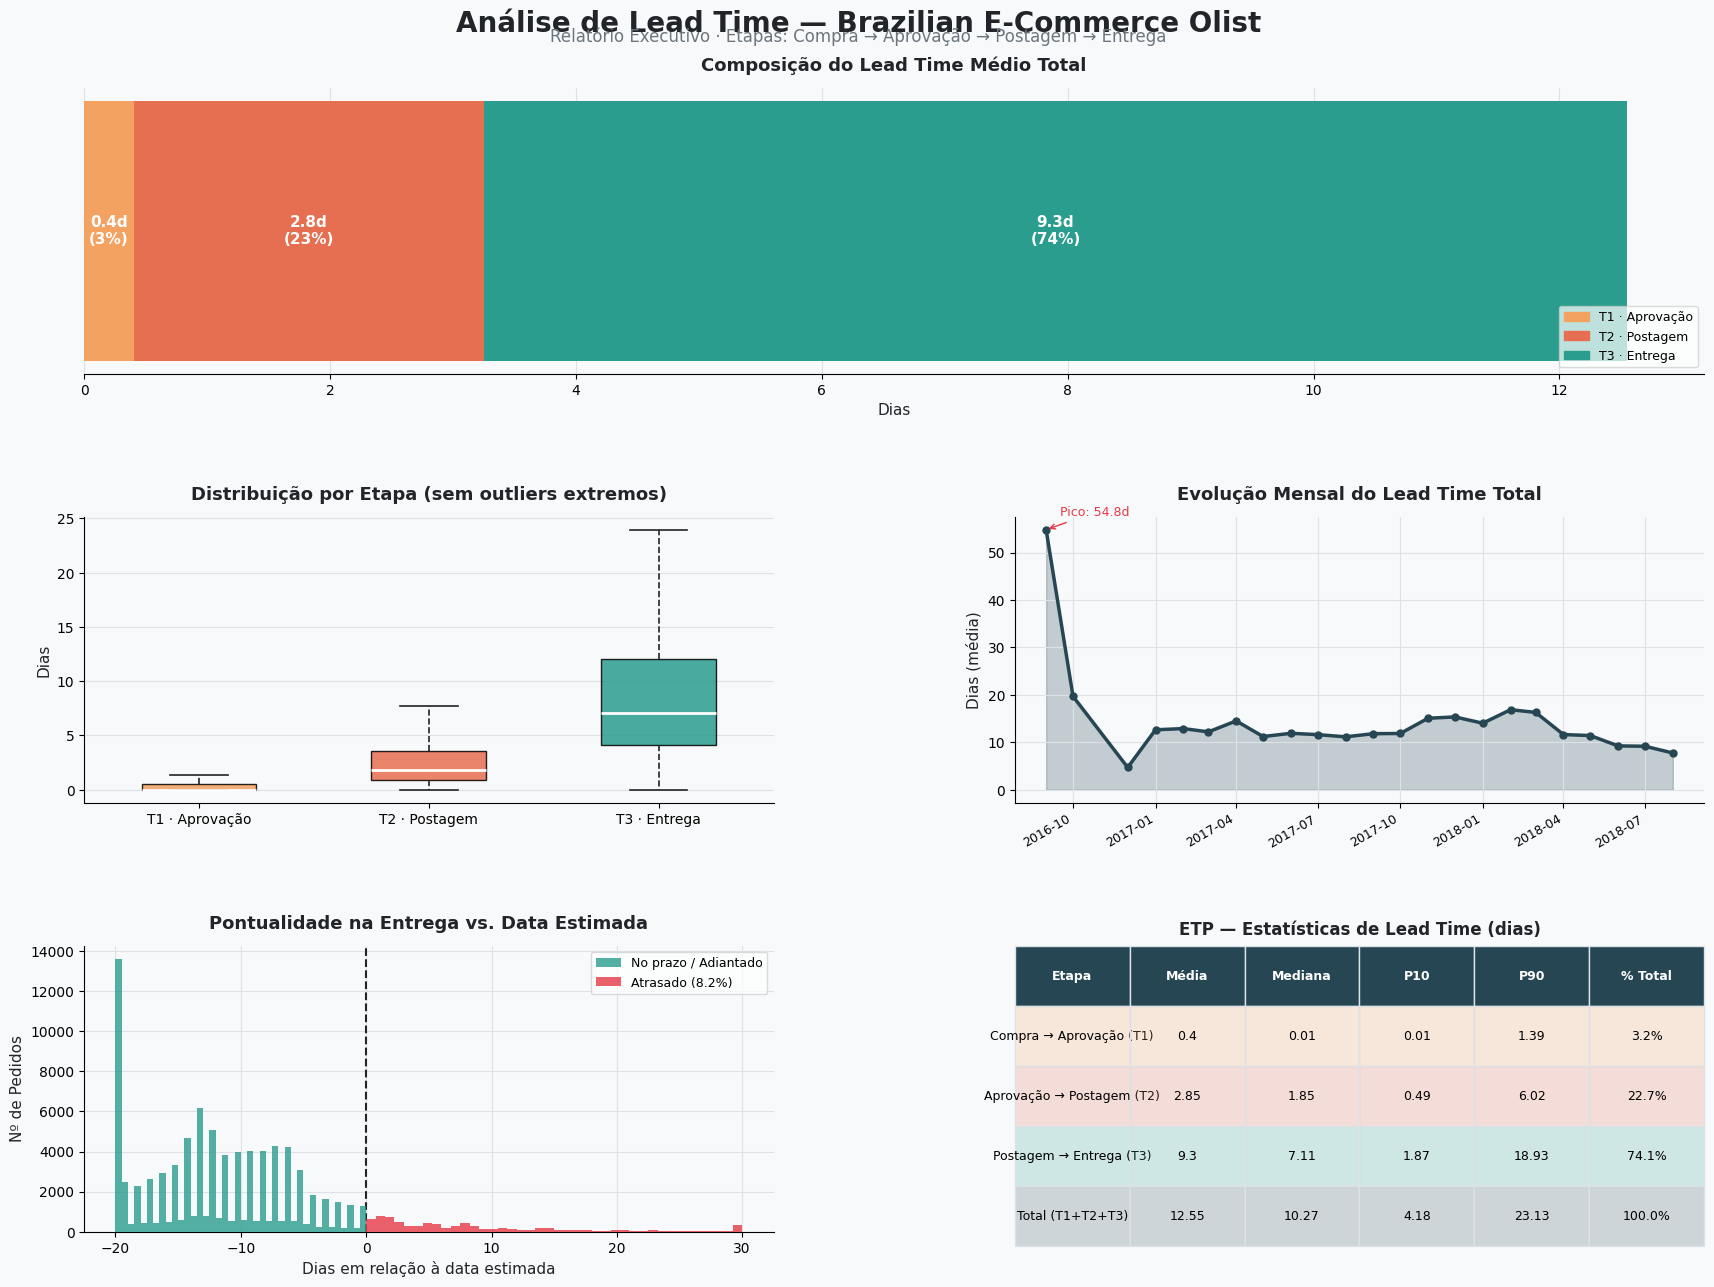

In [ ]:
"""
Análise de Lead Time - Lead Time entre Compra , Aprovação, Postagem e Entrega.

Este script realiza a análise de lead time entre as etapas:
compra → aprovação → postagem → entrega

"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────────────────────────────────────────────── #
#                                1. CARGA DOS DADOS                                        #
# ──────────────────────────────────────────────────────────────────────────────────────── #

def carregar_dados(caminho="./"):
    """
    Carrega os arquivos CSV do dataset Olist.
    Ajuste o caminho (caminho=) para onde seus CSVs estão salvos.
    """
    orders = pd.read_csv(f"{caminho}olist_orders_dataset.csv", parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ])
    return orders

# ──────────────────────────────────────────────────────────────────────────────────────── #
#                           2. ENGENHARIA DE FEATURES (ETP)                                #
# ──────────────────────────────────────────────────────────────────────────────────────── #

def calcular_lead_times(orders: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula as etapas de lead time em horas e dias.

    Etapas:
        T1 – Compra → Aprovação      (aprovação do pagamento)
        T2 – Aprovação → Postagem    (preparação/despacho pelo seller)
        T3 – Postagem → Entrega      (trânsito logístico)
        T_total – Compra → Entrega   (experiência total do cliente)

    Também calcula:
        atraso_dias: diferença entre entrega real e estimada (+ = atrasado)
    """
    df = orders.copy()

    # Filtra apenas pedidos entregues com todas as datas preenchidas
    df = df[df["order_status"] == "delivered"].dropna(subset=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ])

    # Lead times em horas
    df["t1_aprovacao_h"]   = (df["order_approved_at"] - df["order_purchase_timestamp"]).dt.total_seconds() / 3600
    df["t2_postagem_h"]    = (df["order_delivered_carrier_date"] - df["order_approved_at"]).dt.total_seconds() / 3600
    df["t3_entrega_h"]     = (df["order_delivered_customer_date"] - df["order_delivered_carrier_date"]).dt.total_seconds() / 3600
    df["t_total_h"]        = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.total_seconds() / 3600

    # Lead times em dias (mais legível para executivos)
    df["t1_aprovacao_d"]   = df["t1_aprovacao_h"]  / 24
    df["t2_postagem_d"]    = df["t2_postagem_h"]   / 24
    df["t3_entrega_d"]     = df["t3_entrega_h"]    / 24
    df["t_total_d"]        = df["t_total_h"]       / 24

    # Atraso em relação à data estimada
    df["atraso_dias"] = (
        df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
    ).dt.total_seconds() / 86400

    # Remove outliers extremos (janela de 0 a 120 dias para total)
    df = df[
        (df["t_total_d"] > 0) & (df["t_total_d"] <= 120) &
        (df["t1_aprovacao_d"] >= 0) &
        (df["t2_postagem_d"] >= 0) &
        (df["t3_entrega_d"] >= 0)
    ]

    # Coluna ano-mês para análise temporal
    df["ano_mes"] = df["order_purchase_timestamp"].dt.to_period("M")

    return df


def calcular_estatisticas(df: pd.DataFrame) -> pd.DataFrame:
    """
    Retorna tabela ETP com estatísticas descritivas por etapa de lead time.
    ETP = Estatística de Tempo de Processamento
    """
    etapas = {
        "Compra → Aprovação (T1)":  "t1_aprovacao_d",
        "Aprovação → Postagem (T2)":"t2_postagem_d",
        "Postagem → Entrega (T3)":  "t3_entrega_d",
        "Total (T1+T2+T3)":         "t_total_d",
    }

    rows = []
    for nome, col in etapas.items():
        s = df[col]
        rows.append({
            "Etapa":             nome,
            "Média (dias)":      round(s.mean(), 2),
            "Mediana (dias)":    round(s.median(), 2),
            "Desvio Padrão":     round(s.std(), 2),
            "P10 (dias)":        round(s.quantile(0.10), 2),
            "P90 (dias)":        round(s.quantile(0.90), 2),
            "% do Lead Total":   f"{round(s.mean() / df['t_total_d'].mean() * 100, 1)}%"
        })

    etp = pd.DataFrame(rows)
    return etp

# ──────────────────────────────────────────────────────────────────────────────────────── #
#                             3. VISUALIZAÇÕES EXECUTIVAS                                  #
# ──────────────────────────────────────────────────────────────────────────────────────── #

CORES = {
    "t1": "#F4A261",   # Laranja – Aprovação
    "t2": "#E76F51",   # Vermelho – Postagem
    "t3": "#2A9D8F",   # Verde-azul – Entrega
    "total": "#264653",# Azul escuro – Total
    "fundo": "#F8F9FA",
    "grid": "#DEE2E6",
    "texto": "#212529",
    "accent": "#E63946",
}


def grafico_funil_etapas(df: pd.DataFrame, ax: plt.Axes):
    """Barras empilhadas horizontais mostrando composição do lead time."""
    medias = [
        df["t1_aprovacao_d"].mean(),
        df["t2_postagem_d"].mean(),
        df["t3_entrega_d"].mean(),
    ]
    labels = ["T1 · Aprovação", "T2 · Postagem", "T3 · Entrega"]
    cores  = [CORES["t1"], CORES["t2"], CORES["t3"]]

    total = sum(medias)
    left  = 0
    for i, (val, lab, cor) in enumerate(zip(medias, labels, cores)):
        ax.barh(0, val, left=left, color=cor, height=0.5, zorder=3)
        ax.text(left + val/2, 0, f"{val:.1f}d\n({val/total*100:.0f}%)",
                ha="center", va="center", fontsize=11, color="white",
                fontweight="bold")
        left += val

    ax.set_xlim(0, total * 1.05)
    ax.set_yticks([])
    ax.set_xlabel("Dias", fontsize=11, color=CORES["texto"])
    ax.set_title("Composição do Lead Time Médio Total", fontsize=13,
                 fontweight="bold", color=CORES["texto"], pad=12)
    ax.set_facecolor(CORES["fundo"])
    ax.grid(axis="x", color=CORES["grid"], zorder=0)
    ax.spines[["top","right","left"]].set_visible(False)

    legenda = [mpatches.Patch(color=c, label=l) for c, l in zip(cores, labels)]
    ax.legend(handles=legenda, loc="lower right", fontsize=9, framealpha=0.7)


def grafico_boxplot_etapas(df: pd.DataFrame, ax: plt.Axes):
    """Boxplot comparativo das 3 etapas."""
    dados  = [df["t1_aprovacao_d"], df["t2_postagem_d"], df["t3_entrega_d"]]
    labels = ["T1 · Aprovação", "T2 · Postagem", "T3 · Entrega"]
    cores  = [CORES["t1"], CORES["t2"], CORES["t3"]]

    bp = ax.boxplot(dados, vert=True, patch_artist=True,
                    showfliers=False, widths=0.5,
                    medianprops=dict(color="white", linewidth=2))

    for patch, cor in zip(bp["boxes"], cores):
        patch.set_facecolor(cor)
        patch.set_alpha(0.85)

    for whisker in bp["whiskers"]:
        whisker.set(color=CORES["texto"], linewidth=1.2, linestyle="--")
    for cap in bp["caps"]:
        cap.set(color=CORES["texto"], linewidth=1.2)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel("Dias", fontsize=11, color=CORES["texto"])
    ax.set_title("Distribuição por Etapa (sem outliers extremos)",
                 fontsize=13, fontweight="bold", color=CORES["texto"], pad=12)
    ax.set_facecolor(CORES["fundo"])
    ax.grid(axis="y", color=CORES["grid"], zorder=0)
    ax.spines[["top","right"]].set_visible(False)


def grafico_evolucao_mensal(df: pd.DataFrame, ax: plt.Axes):
    """Evolução mensal do lead time total médio."""
    mensal = (
        df.groupby("ano_mes")["t_total_d"]
        .mean()
        .reset_index()
    )
    mensal["mes_dt"] = mensal["ano_mes"].dt.to_timestamp()

    ax.fill_between(mensal["mes_dt"], mensal["t_total_d"],
                    alpha=0.25, color=CORES["total"])
    ax.plot(mensal["mes_dt"], mensal["t_total_d"],
            color=CORES["total"], linewidth=2.5, marker="o", markersize=5)

    # Anotação do pico
    idx_max = mensal["t_total_d"].idxmax()
    ax.annotate(
        f'Pico: {mensal.loc[idx_max, "t_total_d"]:.1f}d',
        xy=(mensal.loc[idx_max, "mes_dt"], mensal.loc[idx_max, "t_total_d"]),
        xytext=(10, 10), textcoords="offset points",
        fontsize=9, color=CORES["accent"],
        arrowprops=dict(arrowstyle="->", color=CORES["accent"])
    )

    ax.set_ylabel("Dias (média)", fontsize=11, color=CORES["texto"])
    ax.set_title("Evolução Mensal do Lead Time Total",
                 fontsize=13, fontweight="bold", color=CORES["texto"], pad=12)
    ax.set_facecolor(CORES["fundo"])
    ax.grid(color=CORES["grid"], zorder=0)
    ax.spines[["top","right"]].set_visible(False)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=9)


def grafico_atraso_dist(df: pd.DataFrame, ax: plt.Axes):
    """Histograma de atraso em relação à data estimada."""
    atraso = df["atraso_dias"].clip(-20, 30)
    n_atrasados = (df["atraso_dias"] > 0).sum()
    pct_atrasados = n_atrasados / len(df) * 100

    ax.hist(atraso[atraso <= 0], bins=40, color=CORES["t3"],
            alpha=0.8, label="No prazo / Adiantado", zorder=3)
    ax.hist(atraso[atraso > 0],  bins=40, color=CORES["accent"],
            alpha=0.8, label=f"Atrasado ({pct_atrasados:.1f}%)", zorder=3)

    ax.axvline(0, color=CORES["texto"], linewidth=1.5, linestyle="--")
    ax.set_xlabel("Dias em relação à data estimada", fontsize=11, color=CORES["texto"])
    ax.set_ylabel("Nº de Pedidos", fontsize=11, color=CORES["texto"])
    ax.set_title("Pontualidade na Entrega vs. Data Estimada",
                 fontsize=13, fontweight="bold", color=CORES["texto"], pad=12)
    ax.legend(fontsize=9, framealpha=0.7)
    ax.set_facecolor(CORES["fundo"])
    ax.grid(color=CORES["grid"], zorder=0)
    ax.spines[["top","right"]].set_visible(False)


def gerar_dashboard(df: pd.DataFrame, etp: pd.DataFrame, salvar="leadtime_olist.png"):
    """Monta o dashboard executivo com 4 gráficos + tabela ETP."""
    fig = plt.figure(figsize=(18, 13), facecolor=CORES["fundo"])
    fig.suptitle(
        "Análise de Lead Time — Brazilian E-Commerce Olist",
        fontsize=20, fontweight="bold", color=CORES["texto"], y=0.98
    )
    fig.text(0.5, 0.955, "Relatório Executivo · Etapas: Compra → Aprovação → Postagem → Entrega",
             ha="center", fontsize=12, color="#6C757D")

    gs = gridspec.GridSpec(3, 2, figure=fig,
                           hspace=0.5, wspace=0.35,
                           left=0.07, right=0.97,
                           top=0.92, bottom=0.04)

    # Gráfico 1 – Funil
    ax1 = fig.add_subplot(gs[0, :])
    grafico_funil_etapas(df, ax1)

    # Gráfico 2 – Boxplot
    ax2 = fig.add_subplot(gs[1, 0])
    grafico_boxplot_etapas(df, ax2)

    # Gráfico 3 – Evolução mensal
    ax3 = fig.add_subplot(gs[1, 1])
    grafico_evolucao_mensal(df, ax3)

    # Gráfico 4 – Atraso
    ax4 = fig.add_subplot(gs[2, 0])
    grafico_atraso_dist(df, ax4)

    # Tabela ETP
    ax5 = fig.add_subplot(gs[2, 1])
    ax5.axis("off")
    ax5.set_title("ETP — Estatísticas de Lead Time (dias)",
                  fontsize=12, fontweight="bold", color=CORES["texto"], pad=8)

    col_labels = ["Etapa", "Média", "Mediana", "P10", "P90", "% Total"]
    table_data = etp[["Etapa","Média (dias)","Mediana (dias)","P10 (dias)","P90 (dias)","% do Lead Total"]].values

    tbl = ax5.table(
        cellText=table_data,
        colLabels=col_labels,
        cellLoc="center", loc="center",
        bbox=[0, -0.05, 1, 1.05]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)

    cores_linha = [CORES["t1"], CORES["t2"], CORES["t3"], CORES["total"]]
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor(CORES["grid"])
        if row == 0:
            cell.set_facecolor(CORES["total"])
            cell.set_text_props(color="white", fontweight="bold")
        elif 1 <= row <= 4:
            c = cores_linha[row - 1]
            cell.set_facecolor(c + "33")  # transparência
        else:
            cell.set_facecolor("white")

    plt.savefig(salvar, dpi=150, bbox_inches="tight",
                facecolor=CORES["fundo"])
    print(f"\n✅ Dashboard salvo em: {salvar}")
    plt.show()

# ──────────────────────────────────────────────────────────────────────────────────────── #
#                              4. EXECUÇÃO PRINCIPAL                                       #
# ──────────────────────────────────────────────────────────────────────────────────────── #

if __name__ == "__main__":
    print("=" * 100)
    print("                              ANÁLISE DE LEAD TIME — OLIST E-COMMERCE" )
    print("=" * 100)

# ── CARREGAMENTO ──────────────────────────────────────────
    # Ajuste o caminho para a pasta onde estão os CSVs do Olist
    CAMINHO_DADOS = "./"       # Ex: "/content/drive/MyDrive/olist/"

    print("\n📂 Carregando dados...")
    orders = carregar_dados(CAMINHO_DADOS)
    print(f"   {len(orders):,} pedidos carregados.")

    # ── PROCESSAMENTO ─────────────────────────────────────────
    print("\n⚙️  Calculando lead times...")
    df = calcular_lead_times(orders)
    print(f"   {len(df):,} pedidos entregues válidos para análise.")

    # ── ETP ───────────────────────────────────────────────────
    etp = calcular_estatisticas(df)
    print("\n📊 ETP — Estatísticas de Lead Time:\n")
    print(etp.to_string(index=False))

    # ── DASHBOARD ─────────────────────────────────────────────
    print("\n🖼️  Gerando dashboard executivo...")
    gerar_dashboard(df, etp, salvar="leadtime_olist.png")



##### **5.2 Correlação entre atrasos e review_score.**
</br>


**Importação de bibliotecas e carregamento de dados** <br>
Tabelas necessárias para análise de correlação entre atrasos e review_score: <br>


*   Orders: contém as datas de entrega prevista e real de cada pedido
*   Reviews: contém as notas (review_score) dadas pelos clientes
*   Items: contém preço e frete, úteis para análises complementares







In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

orders = pd.read_csv("/content/olist_orders_dataset.csv")
reviews = pd.read_csv("/content/olist_order_reviews_dataset.csv")
items = pd.read_csv("/content/olist_order_items_dataset.csv")

**Conversão de datas e cálculo do atraso** <br>
As colunas de data chegam como texto (string). Primeiro, é preciso convertê-las para o tipo datetime do pandas, que permite operações matemáticas entre datas. Em seguida, criamos a variável central desta análise: 'atraso_dias', que mede a diferença entre a data de entrega real e a data prometida:
*   (menor que) 0: pedido chegou atrasado
*   = 0: pedido chegou exatamente no prazo
*   < 0: pedido chegou adiantado




In [ ]:
#date_cols armazena os nomes das duas colunas de data que precisam ser convertidas
date_cols = [
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

#faz a conversão de texto para datetime do pandas
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders['atraso_dias'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']
).dt.days

# Conferindo os tipos após a conversão
print(orders[date_cols].dtypes)

# Visualização de como ficou a nova coluna atraso_dias
print(orders[['order_delivered_customer_date',
              'order_estimated_delivery_date',
              'atraso_dias']].head())

# Estatísticas básicas do atraso (mín, máx, média)
print(orders['atraso_dias'].describe())

order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object
  order_delivered_customer_date order_estimated_delivery_date  atraso_dias
0           2017-10-10 21:25:13                    2017-10-18         -8.0
1           2018-08-07 15:27:45                    2018-08-13         -6.0
2           2018-08-17 18:06:29                    2018-09-04        -18.0
3           2017-12-02 00:28:42                    2017-12-15        -13.0
4           2018-02-16 18:17:02                    2018-02-26        -10.0
count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: atraso_dias, dtype: float64


**Filtro de pedidos entregues e união com reviews** <br>
A análise foi restrita apenas a pedidos com status 'delivered', pois são os únicos que possuem data de entrega real preenchida e review válido. Pedidos cancelados, em trânsito ou sem entrega confirmada seriam ruído.

O merge une cada pedido à sua respectiva avaliação pelo campo order_id. O comando 'inner join' para manter apenas pedidos que possuem review registrado.

In [ ]:
#mantém apenas os pedidos entregues com data real e review válido
orders_entregues = orders[orders['order_status'] == 'delivered'].copy()

#une pedidos com suas respectivas notas pelo order_id
df = orders_entregues.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

# Remove as linhas sem data de entrega real (apenas 8 casos)
df = df.dropna(subset=['atraso_dias', 'review_score'])

print(f"Base final: {len(df):,} pedidos")

Base final: 96,353 pedidos


**Classificação da situação de entrega** <br>
Foi criada uma variável categórica para agrupar os pedidos em três situações: pedido entregue adiantado, no prazo e atrasado. Isso permite a comparação entre a nota média de cada grupo e visualização de forma clara como o cumprimento (ou não) do prazo afeta a satisfação do cliente.

In [ ]:
#função que classifica cada pedido com base nos dias de atraso
def classificar_entrega(dias):
    if pd.isna(dias): return 'sem_info'
    elif dias < 0: return 'adiantado'
    elif dias == 0: return 'no_prazo'
    else: return 'atrasado'

#aplica a função em cada linha da coluna atraso_dias
df['situacao_entrega'] = df['atraso_dias'].apply(classificar_entrega)

#exibe a quantidade de pedidos em cada situação
print(df['situacao_entrega'].value_counts())

situacao_entrega
adiantado    88653
atrasado      6409
no_prazo      1291
Name: count, dtype: int64


**Análise estatística** <br>
Foi utilizada a correlação de Spearman (mais robusta que Pearson para dados ordinais como review_score) e a nota média por situação de entrega. Um coeficiente negativo confirma: quanto maior o atraso, menor a nota.

In [ ]:
#calcula a correlação de spearman entre o atraso e a nota do cliente
corr, pvalor = stats.spearmanr(df['atraso_dias'], df['review_score'])
print(f"Correlação de Spearman: {corr:.4f} (p-valor: {pvalor:.2e})")

#calcula a nota média agrupada por sutuação de entrega
media_por_situacao = df.groupby('situacao_entrega')['review_score'].mean().round(2)
print("\nNota média por situação de entrega:")
print(media_por_situacao)

Correlação de Spearman: -0.1762 (p-valor: 0.00e+00)

Nota média por situação de entrega:
situacao_entrega
adiantado    4.29
atrasado     2.27
no_prazo     4.03
Name: review_score, dtype: float64


**Visualizações** <br>
Foram gerados dois gráficos complementares: o Boxplot, que mostra a distribuição completa das notas por situação de entrega e o Barbplot, que destaca a diferença de nota média entre os três grupos. Juntos, eles tornam visível o impacto do atraso para o relatório executivo.


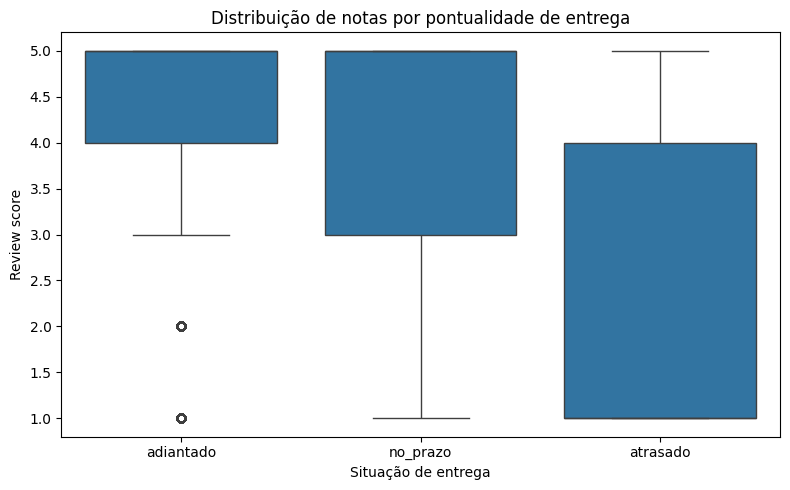

In [ ]:
#Boxplot
#define a ordem de exibição das categorias no eixo x
ordem = ['adiantado', 'no_prazo', 'atrasado']

fig, ax = plt.subplots(figsize=(8, 5))

#Gera o boxplot com a distribuição completa das notas por situação
sns.boxplot(data=df, x='situacao_entrega', y='review_score',
            order=ordem, ax=ax)

#Títulos e rótulos dos eixos
ax.set_title('Distribuição de notas por pontualidade de entrega')
ax.set_xlabel('Situação de entrega')
ax.set_ylabel('Review score')

#Ajusta o espaçamento para os elementos não se sorbeporem
plt.tight_layout()

#Exibe o gráfico
plt.show()

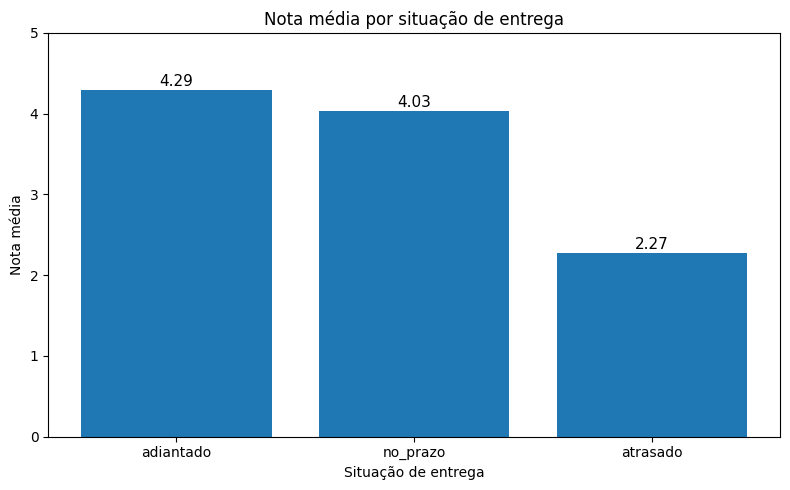

In [ ]:
#Barplot
fig, ax = plt.subplots(figsize=(8, 5))

#Calcula a nota média por situação e reordena conforme a ordem definida
medias = df.groupby('situacao_entrega')['review_score'].mean().reindex(ordem)

#Gera o barplot e define o eixo y de 0 a 5 (escala do review_score)
ax.bar(ordem, medias.values)
ax.set_ylim(0, 5)

#Títulos e rótulos dos eixos
ax.set_title('Nota média por situação de entrega')
ax.set_xlabel('Situação de entrega')
ax.set_ylabel('Nota média')

#Adiciona o valor numérico acima de cada barra
for i, v in enumerate(medias.values):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=11)

#Ajusta o espaçamento para os elementos não se sobreporem
plt.tight_layout()

#Exibe o gráfico
plt.show()


##### 5.3 Mapa de calor de desempenho por região.
</br>


uf  avg_score  n_reviews
AP   4.194030         67
AM   4.183673        147
PR   4.180032       5038
SP   4.173951      41690
MG   4.136172      11625
RS   4.133321       5483
MS   4.118785        724
RN   4.105809        482
MT   4.102990        903
TO   4.096774        279
SC   4.071764       3623
DF   4.064711       2148
RO   4.051587        252
AC   4.049383         81
GO   4.042490       2024
ES   4.041667       2016
PB   4.018832        531
PE   4.011543       1646
PI   3.920570        491
RJ   3.874971      12765
BA   3.860888       3357
CE   3.851016       1329
PA   3.849174        968
SE   3.808023        349
MA   3.764075        746
AL   3.751208        414
RR   3.608696         46

Média geral: 4.086
Baixando shapefile dos estados do IBGE...

Mapa salvo em: mapa_brasil_review_score.png


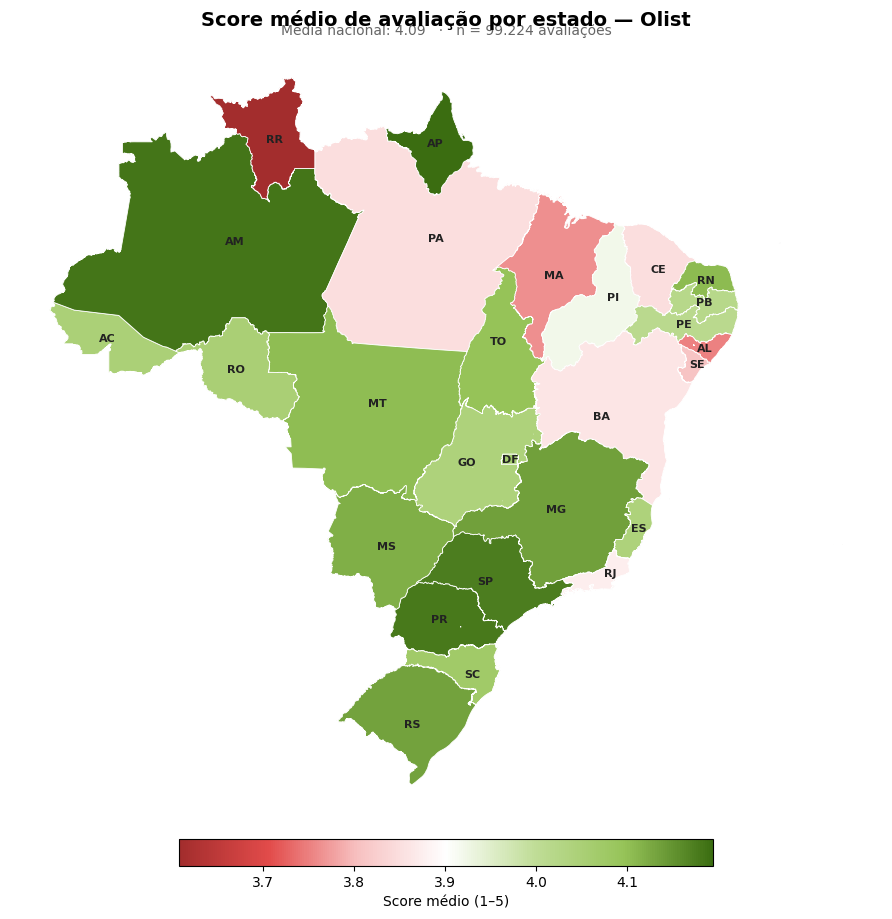

In [ ]:
"Mapa de calor da avaliação de desempenho por estado"
import io
import json
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import requests
from matplotlib.colors import LinearSegmentedColormap

# ---------------------------------------------------------------------------
# 1. Carregar os dados do Olist e calcular a média por estado
# ---------------------------------------------------------------------------

BASE = Path('/content/') # Define BASE path

reviews   = pd.read_csv(BASE / 'olist_order_reviews_dataset.csv')
orders    = pd.read_csv(BASE / 'olist_orders_dataset.csv')
customers = pd.read_csv(BASE / 'olist_customers_dataset.csv')

# Encadear reviews -> orders -> customers para chegar ao estado do cliente
df = (reviews
      .merge(orders[['order_id', 'customer_id']], on='order_id', how='inner')
      .merge(customers[['customer_id', 'customer_state']], on='customer_id', how='inner'))

state_stats = (df.groupby('customer_state')['review_score']
                 .agg(['mean', 'count'])
                 .reset_index()
                 .rename(columns={'customer_state': 'uf',
                                  'mean': 'avg_score',
                                  'count': 'n_reviews'}))

state_stats.to_csv('state_scores.csv', index=False)
media_geral = df['review_score'].mean()
print(state_stats.sort_values('avg_score', ascending=False).to_string(index=False))
print(f'\nMédia geral: {media_geral:.3f}')

# ---------------------------------------------------------------------------
# 2. Baixar o shapefile dos estados do Brasil (IBGE, via GitHub)
# ---------------------------------------------------------------------------
# Usamos o repositório público "br-atlas" que empacota os shapes do IBGE.
# A primeira execução baixa; depois ele fica em cache local.
SHP_DIR = Path('br_shapefile')
SHP_FILE = SHP_DIR / 'BR_UF_2022.shp'

if not SHP_FILE.exists():
    print('Baixando shapefile dos estados do IBGE...')
    url = ('https://geoftp.ibge.gov.br/organizacao_do_territorio/'
           'malhas_territoriais/malhas_municipais/municipio_2022/Brasil/BR/BR_UF_2022.zip')
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    SHP_DIR.mkdir(exist_ok=True)
    with zipfile.ZipFile(io.BytesIO(r.content)) as zf:
        zf.extractall(SHP_DIR)

gdf = gpd.read_file(SHP_FILE)
# O shapefile do IBGE traz a sigla em 'SIGLA_UF'
gdf = gdf.rename(columns={'SIGLA_UF': 'uf'})[['uf', 'geometry']]

# ---------------------------------------------------------------------------
# 3. Juntar geometria + score
# ---------------------------------------------------------------------------
gdf = gdf.merge(state_stats, on='uf', how='left')

# ---------------------------------------------------------------------------
# 4. Desenhar o mapa
# ---------------------------------------------------------------------------
# Colormap divergente: vermelho (pior) -> branco (média) -> verde (melhor)
cmap = LinearSegmentedColormap.from_list(
    'score', ['#A32D2D', '#E24B4A', '#F7C1C1', '#FFFFFF',
             '#C0DD97', '#97C459', '#3B6D11'])

fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column='avg_score',
    cmap=cmap,
    linewidth=0.6,
    edgecolor='white',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': 'Score médio (1–5)',
        'orientation': 'horizontal',
        'shrink': 0.55,
        'pad': 0.02,
    },
    missing_kwds={'color': '#eeeeee', 'label': 'sem dados'},
)

# Rótulos com a sigla da UF no centroide de cada estado
# (usamos representative_point para evitar labels fora do polígono em estados recortados)
for _, row in gdf.iterrows():
    if row['geometry'] is None:
        continue
    pt = row['geometry'].representative_point()
    ax.annotate(
        row['uf'],
        xy=(pt.x, pt.y),
        ha='center', va='center',
        fontsize=8, fontweight='bold', color='#222',
    )

ax.set_title('Score médio de avaliação por estado — Olist',
             fontsize=14, fontweight='bold', pad=12)
ax.text(0.5, 1.01,
        f'Média nacional: {media_geral:.2f}   ·   n = {len(df):,} avaliações'.replace(',', '.'),
        transform=ax.transAxes, ha='center', fontsize=10, color='#666')
ax.set_axis_off()

plt.tight_layout()
plt.savefig('mapa_brasil_review_score.png', dpi=200, bbox_inches='tight')
print('\nMapa salvo em: mapa_brasil_review_score.png')


##### **5.4 Distribuição de review_score e temas recorrentes.**
</br>


 Bloco 1: Imports e Carregamento da Base

 Nesta etapa, o objetivo é cruzar a fronteira entre os números operacionais e o sentimento real do consumidor.

Começamos com uma análise quantitativa da distribuição do `review_score`. O intuito é dimensionar a nossa base de clientes, entendendo a proporção exata entre os **Promotores** (que dão notas altas e são leais à marca) e os **Detratores** (que penalizam a marca com notas baixas), estabelecendo o tamanho do problema que precisamos investigar.

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
import re
from collections import Counter


nltk.download('stopwords')


reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
print("Base de dados carregada com sucesso a partir da pasta /content/!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Base de dados carregada com sucesso a partir da pasta /content/!


Bloco 2: Gerar o Gráfico de Distribuição

Preparação dos Dados Qualitativos (Text Mining)


Como os textos livres contêm muito ruído estrutural, aplicamos técnicas de Processamento de Linguagem Natural (NLP). Filtramos apenas as avaliações que contêm mensagens escritas e realizamos uma "limpeza": removemos pontuações e *stopwords* (palavras vazias sem valor analítico, como 'e', 'de', 'produto', 'comprei'). Isso nos deixa apenas com o núcleo semântico da reclamação ou do elogio.

/tmp/ipykernel_18529/954629749.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews, x='review_score', palette='viridis', ax=ax)


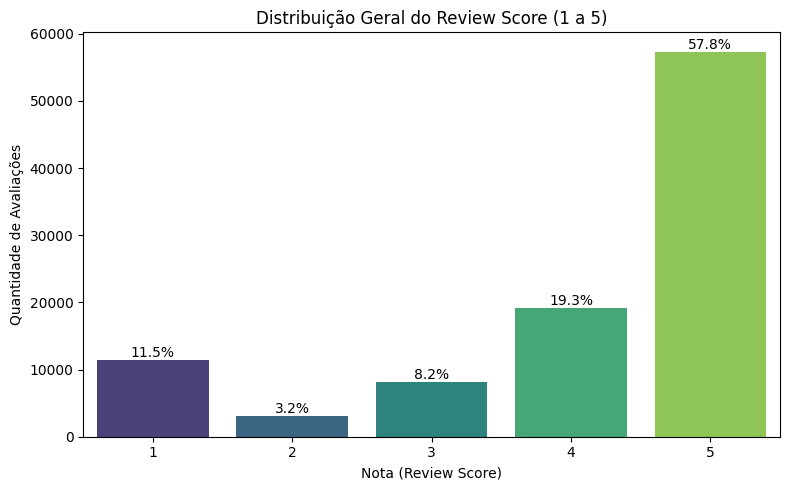

In [ ]:

# Calcular a distribuição em porcentagem
distribuicao_notas = reviews['review_score'].value_counts(normalize=True).sort_index() * 100

# Criar o gráfico de barras
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=reviews, x='review_score', palette='viridis', ax=ax)

ax.set_title('Distribuição Geral do Review Score (1 a 5)')
ax.set_xlabel('Nota (Review Score)')
ax.set_ylabel('Quantidade de Avaliações')

# Adicionar os percentuais em cima de cada barra
for p in ax.patches:
    altura = p.get_height()
    porcentagem = f'{(altura/len(reviews))*100:.1f}%'
    ax.annotate(porcentagem, (p.get_x() + p.get_width() / 2., altura),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

 Bloco 3: Preparação e Limpeza dos Textos

In [ ]:


reviews_com_texto = reviews.dropna(subset=['review_comment_message']).copy()


stop_words_pt = set(stopwords.words('portuguese'))
# Adicionando palavras muito comuns que não ajudam a entender o problema/solução
stop_words_pt.update(['produto', 'comprei', 'compra', 'veio', 'loja', 'entregue', 'chegou', 'recebi', 'prazo', 'dia', 'antes', 'recomendo'])

def limpar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-záéíóúâêôãõç\s]', '', texto)
    palavras = texto.split()

    palavras_limpas = [p for p in palavras if p not in stop_words_pt and len(p) > 2]
    return palavras_limpas

# Aplicar a função para limpar os textos
print("Limpando os textos... Aguarde um momento.")
reviews_com_texto['palavras_limpas'] = reviews_com_texto['review_comment_message'].apply(limpar_texto)
print("Limpeza concluída com sucesso!")

Limpando os textos... Aguarde um momento.
Limpeza concluída com sucesso!


Bloco 4: Extração dos Temas Recorrentes

Com a base de textos higienizada, dividimos os clientes nos dois extremos de satisfação: **Detratores** (notas 1 e 2) e **Promotores** (nota 5).

Ao extrair e contabilizar os temas mais recorrentes em cada grupo, o objetivo é encontrar a causa raiz da insatisfação. Esta análise qualitativa serve como a "prova social" para validar as hipóteses levantadas nas análises de Lead Time e Atrasos (seções anteriores), demonstrando visualmente aos acionistas qual gargalo operacional tem o maior poder de destruição de valor e de marca.

In [ ]:

# Separar Detratores (notas 1 e 2) e Promotores (nota 5)
detratores = reviews_com_texto[reviews_com_texto['review_score'] <= 2]
promotores = reviews_com_texto[reviews_com_texto['review_score'] == 5]

# Função para contar as palavras mais frequentes
def contar_palavras(df_filtrado):
    todas_palavras = []
    for lista in df_filtrado['palavras_limpas']:
        todas_palavras.extend(lista)
    return Counter(todas_palavras).most_common(10)

top_detratores = contar_palavras(detratores)
top_promotores = contar_palavras(promotores)

print(" TOP 10 TEMAS - DETRATORES (Notas 1 e 2):")
for palavra, contagem in top_detratores:
    print(f"- {palavra}: {contagem} vezes")

print("\n TOP 10 TEMAS - PROMOTORES (Nota 5):")
for palavra, contagem in top_promotores:
    print(f"- {palavra}: {contagem} vezes")

 TOP 10 TEMAS - DETRATORES (Notas 1 e 2):
- entrega: 1393 vezes
- ainda: 1385 vezes
- nao: 935 vezes
- pedido: 779 vezes
- agora: 684 vezes
- apenas: 538 vezes
- nada: 508 vezes
- produtos: 508 vezes
- pois: 504 vezes
- site: 504 vezes

 TOP 10 TEMAS - PROMOTORES (Nota 5):
- entrega: 3618 vezes
- bom: 2896 vezes
- bem: 2179 vezes
- qualidade: 1713 vezes
- tudo: 1623 vezes
- excelente: 1588 vezes
- ótimo: 1501 vezes
- super: 1432 vezes
- rápida: 1123 vezes
- gostei: 1026 vezes


 Bloco 5: Visualização dos Temas Recorrentes

/tmp/ipykernel_18529/3010877558.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_detratores, y='Palavra', x='Frequência', ax=axes[0], palette='Reds_r')
/tmp/ipykernel_18529/3010877558.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_promotores, y='Palavra', x='Frequência', ax=axes[1], palette='Greens_r')


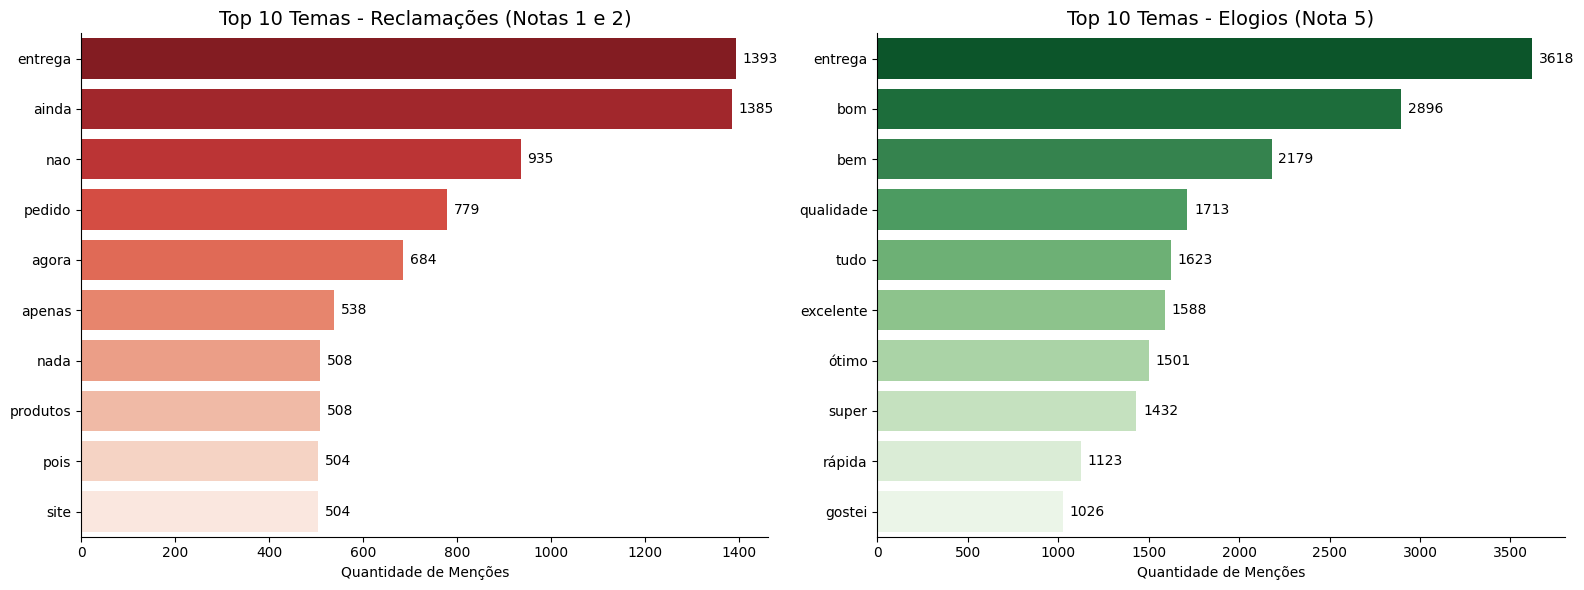

In [ ]:


df_detratores = pd.DataFrame(top_detratores, columns=['Palavra', 'Frequência'])
df_promotores = pd.DataFrame(top_promotores, columns=['Palavra', 'Frequência'])


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Detratores (Vermelho)
sns.barplot(data=df_detratores, y='Palavra', x='Frequência', ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Temas - Reclamações (Notas 1 e 2)', fontsize=14)
axes[0].set_xlabel('Quantidade de Menções')
axes[0].set_ylabel('')

# Gráfico 2: Promotores (Verde)
sns.barplot(data=df_promotores, y='Palavra', x='Frequência', ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Temas - Elogios (Nota 5)', fontsize=14)
axes[1].set_xlabel('Quantidade de Menções')
axes[1].set_ylabel('')


for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}',
                    (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(5, 0), textcoords='offset points', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

##### **5.5 Drivers de satisfação: NPS e CSAT.**
</br>
</br>

##### **NPS (Net Promoter Scores) - Identificar quem recomendaria ou não, e porquê.**

---
- separar as recomendadas (review score 5) que contenham a palavra "recomen..." na coluna review_comment_title, buscar palavras qualitativas na coluna review_comment_message
- separar as não recomendadas (review score 1,2) que contenham a palavra "recomen..." na coluna review_comment_title, buscar palavras qualitativas na coluna review_comment_message que identifiquem o problema que tiveram
---

</br>
</br>

##### **CSAT (Customer Satisfaction Scores) - Identificar as experiências ruins.**
---
- explorar os top sellers (melhores e piores)
- explorar os causas (satisfação e insatisfação)
---



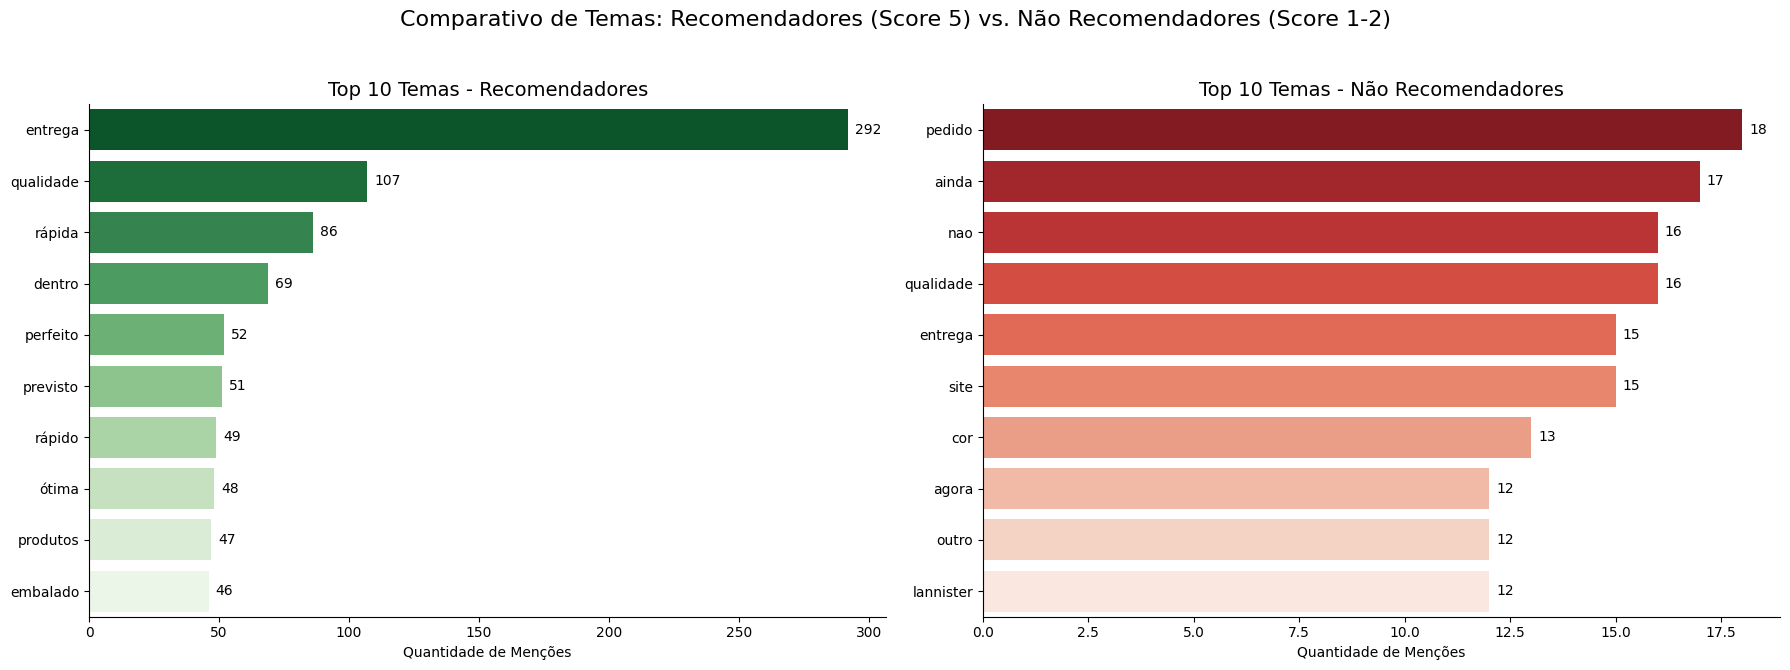


--- Análise Percentual de Recomendações ---
Total de recomendações analisadas (com 'recomen' no título): 1796
Recomendações Positivas (score 5): 1585 (88.25%)
Recomendações Negativas (score 1-2): 211 (11.75%)


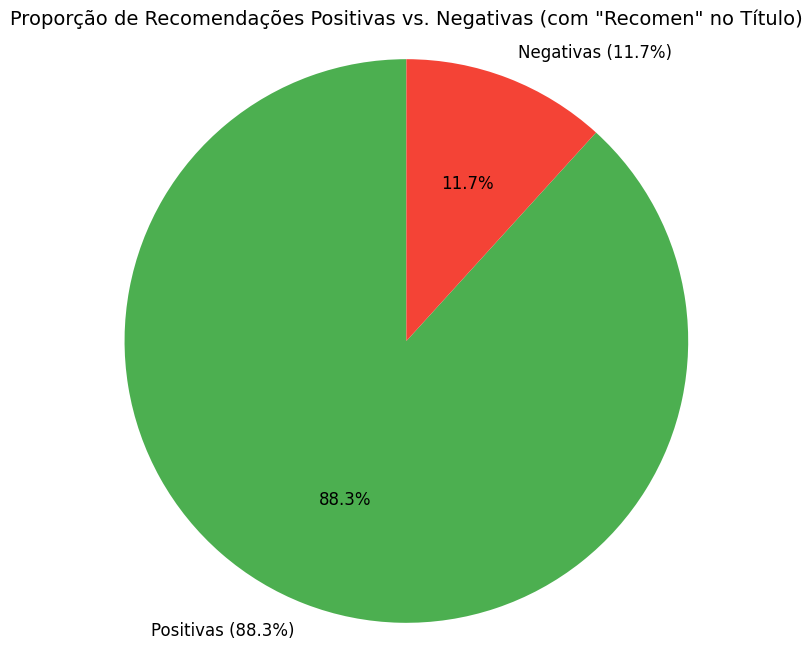

In [ ]:
#NPS

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# criando os dataframes recomendados x não recomendados
df_reasons = pd.DataFrame(top_10_reasons, columns=['Palavra', 'Frequência'])
df_reasons_not_recommended = pd.DataFrame(top_10_reasons_not_recommended, columns=['Palavra', 'Frequência'])
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Comparativo de Temas: Recomendadores (Score 5) vs. Não Recomendadores (Score 1-2)', fontsize=16)

# Gráfico 1: Recomendadores (Verde)
sns.barplot(data=df_reasons.sort_values(by='Frequência', ascending=False),
            y='Palavra', x='Frequência', ax=axes[0], palette='Greens_r', hue='Palavra', legend=False)
axes[0].set_title('Top 10 Temas - Recomendadores', fontsize=14)
axes[0].set_xlabel('Quantidade de Menções')
axes[0].set_ylabel('')

# Adiciona os valores nas barras
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_width())}',
                     (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha='left', va='center',
                     xytext=(5, 0), textcoords='offset points', fontsize=10)

# Gráfico 2: Não Recomendadores (Vermelho)
sns.barplot(data=df_reasons_not_recommended.sort_values(by='Frequência', ascending=False),
            y='Palavra', x='Frequência', ax=axes[1], palette='Reds_r', hue='Palavra', legend=False)
axes[1].set_title('Top 10 Temas - Não Recomendadores', fontsize=14)
axes[1].set_xlabel('Quantidade de Menções')
axes[1].set_ylabel('')

# Adiciona os valores nas barras
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_width())}',
                     (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha='left', va='center',
                     xytext=(5, 0), textcoords='offset points', fontsize=10)

sns.despine()
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta o layout para evitar sobreposição do título principal
plt.show()


# Contagem de recomendações positivas e negativas
count_positive = len(reviews_filtered)
count_negative = len(reviews_not_recommended)

# Total de reviews analisadas que contêm 'recomen...' no título e são de score 5 ou 1-2
total_recommendations_analyzed = count_positive + count_negative

if total_recommendations_analyzed > 0:
    # Calcular porcentagens
    pct_positive = (count_positive / total_recommendations_analyzed) * 100
    pct_negative = (count_negative / total_recommendations_analyzed) * 100

    print(f"\n--- Análise Percentual de Recomendações ---")
    print(f"Total de recomendações analisadas (com 'recomen' no título): {total_recommendations_analyzed}")
    print(f"Recomendações Positivas (score 5): {count_positive} ({pct_positive:.2f}%)")
    print(f"Recomendações Negativas (score 1-2): {count_negative} ({pct_negative:.2f}%)")

    # Visualização em gráfico de pizza
    labels = [f'Positivas ({pct_positive:.1f}%)', f'Negativas ({pct_negative:.1f}%)']
    sizes = [pct_positive, pct_negative]
    colors = ['#4CAF50', '#F44336'] # Verde para positivo, Vermelho para negativo

    fig1, ax1 = plt.subplots(figsize=(8, 8))
    ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12, 'color': 'black'})
    ax1.axis('equal')  # Garante que o gráfico de pizza seja circular.
    plt.title('Proporção de Recomendações Positivas vs. Negativas (com "Recomen" no Título)', fontsize=14)
    plt.show()
else:
    print("Não há recomendações positivas ou negativas com 'recomen' no título para calcular a porcentagem.")



### **CSAT - Análise dos Sellers (Vendedores)**

Esta seção visa identificar os vendedores com melhor e pior desempenho em termos de satisfação do cliente (baseado nas notas de avaliação) e explorar os fatores qualitativos que contribuem para essa performance.

Datasets 'reviews' e 'order_items' carregados com sucesso.
Base unificada de reviews por vendedor criada com 99247 registros.

--- Top 10 Melhores Vendedores (acima de 50 reviews) ---
                             seller_id  mean_review_score  num_reviews
2526  d13e50eaa47b4cbe9eb81465865d8cfc           4.820896           67
2624  d9bd94811c3338dceb4181f3dbc0c73e           4.796296           54
2575  d566c37fa119d5e66c4e9052e83ee4ea           4.687500           64
646   376a891762bbdecbc02b4b6adec3fdda           4.666667           57
201   116ccb1a1604bc88e4d234a8c23f33de           4.639344           61
322   1bb2bdb95f4841f1bba2c0d2cd83d3c9           4.637500           80
100   080199a181c46c657dc5aa235411be3b           4.615385           78
2073  ac3508719a1d8f5b7614b798f70af136           4.603960          101
1120  5b925e1d006e9476d738aa200751b73b           4.603175           63
2797  e882b2a25a10b9c057cc49695f222c19           4.578947           57

--- Top 10 Temas Recorrentes nas A

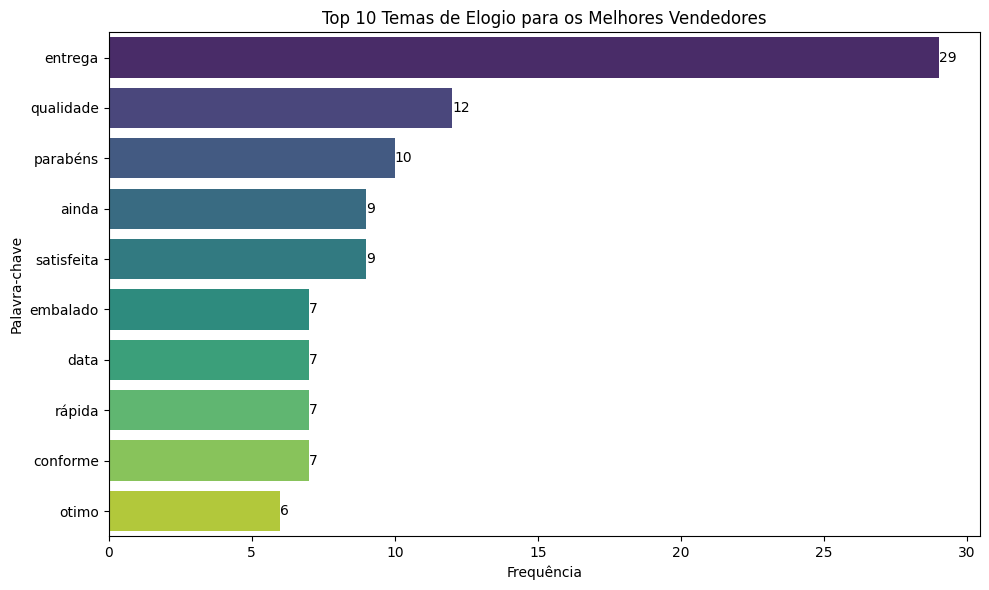


--- Top 10 Piores Vendedores (acima de 50 reviews) ---
                             seller_id  mean_review_score  num_reviews
333   1ca7077d890b907f89be8c954a02686a           2.333333          114
553   2eb70248d66e0e3ef83659f71b244378           2.691919          198
1029  54965bbe3e4f07ae045b90b0b8541f52           3.000000           74
2000  a49928bcdf77c55c6d6e05e09a9b4ca5           3.010204           98
1842  972d0f9cf61b499a4812cf0bfa3ad3c4           3.025316           79
491   2a1348e9addc1af5aaa619b1a3679d6b           3.117647           51
2253  bbad7e518d7af88a0897397ffdca1979           3.161765           68
959   5058e8c1e82653974541e83690655b4a           3.241935           62
1622  8444e55c1f13cd5c179851e5ca5ebd00           3.262626           99
2035  a7f13822ceb966b076af67121f87b063           3.337838           74

--- Top 10 Temas Recorrentes nas Avaliações NEGATIVAS dos Piores Vendedores ---
- relógio: 33 vezes
- qualidade: 30 vezes
- ainda: 25 vezes
- diferente: 23 vezes


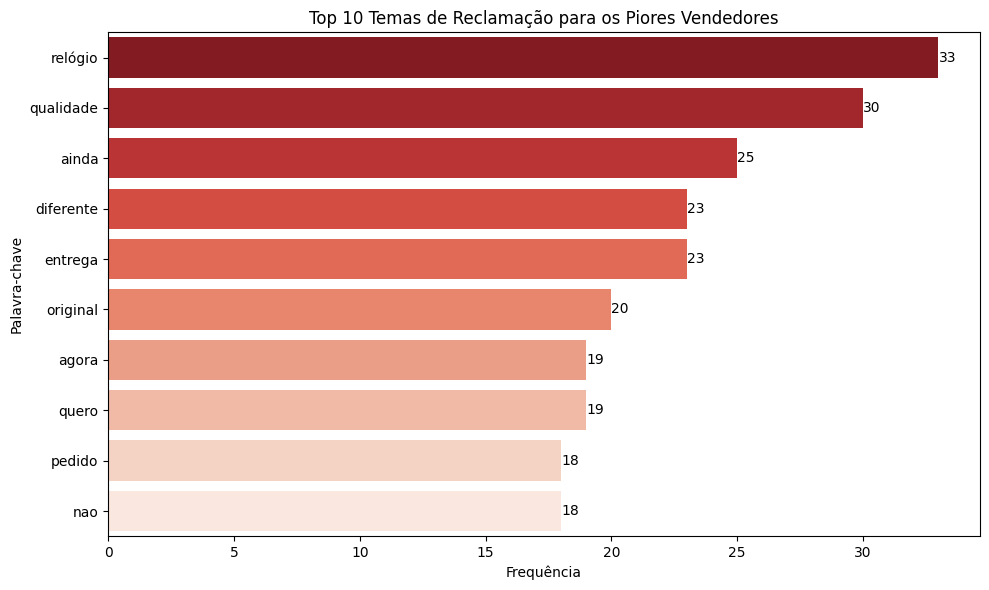


Faturamento Total da Plataforma: R$ 14,250,018.25
Faturamento Total das Piores Categorias: R$ 3,852,301.53
Impacto Percentual das Piores Categorias no Faturamento Total: 27.03%


In [ ]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
import re

# Baixar stopwords (se ainda não estiver baixado)
nltk.download('stopwords', quiet=True)

# Re-definir a função limpar_texto e stop_words_pt para garantir que esteja disponível
stop_words_pt = set(stopwords.words('portuguese'))
stop_words_pt.update([
    'produto', 'comprei', 'compra', 'veio', 'loja', 'entregue', 'chegou',
    'recebi', 'prazo', 'dia', 'antes', 'recomendo', 'recomendar', 'muito',
    'super', 'bom', 'excelente', 'ótimo', 'tudo', 'bem', 'gostei'
])

def limpar_texto(texto):
    if pd.isna(texto):
        return []
    texto = str(texto).lower()
    texto = re.sub(r'[^a-záéíóúâêôãõç\s]', '', texto)
    palavras = texto.split()
    palavras_limpas = [p for p in palavras if p not in stop_words_pt and len(p) > 2]
    return palavras_limpas

# Carregar os datasets (reviews já está carregado do prompt anterior)
# reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv') # Já carregado
order_items = pd.read_csv('/content/olist_order_items_dataset.csv')

print("Datasets 'reviews' e 'order_items' carregados com sucesso.")

# 1. Unir reviews com order_items para associar review_score ao seller_id
# Criar uma cópia do reviews para evitar SettingWithCopyWarning
reviews_copy = reviews.copy()
df_seller_reviews = pd.merge(reviews_copy, order_items, on='order_id', how='inner')

# Remover duplicatas de order_id + seller_id, mantendo apenas uma review por item/seller
# Se houver múltiplas reviews para o mesmo item/seller, a primeira é mantida
df_seller_reviews.drop_duplicates(subset=['order_id', 'seller_id'], inplace=True)

print(f"Base unificada de reviews por vendedor criada com {len(df_seller_reviews)} registros.")

# 2. Calcular a média de review_score por vendedor
seller_performance = df_seller_reviews.groupby('seller_id').agg(
    mean_review_score=('review_score', 'mean'),
    num_reviews=('review_score', 'count')
).reset_index()

# Definir um limite mínimo de reviews para considerar um vendedor
min_reviews_threshold = 50 # Exemplo: Vendedores com pelo menos 50 reviews
seller_performance = seller_performance[seller_performance['num_reviews'] >= min_reviews_threshold]

# Ordenar para encontrar os melhores vendedores
top_sellers = seller_performance.sort_values(by='mean_review_score', ascending=False).head(10)

print("\n--- Top 10 Melhores Vendedores (acima de 50 reviews) ---")
print(top_sellers)

# 3. Analisar as mensagens de review dos top sellers para entender os 'porquês'
# Filtrar reviews pertencentes aos top sellers
top_seller_ids = top_sellers['seller_id'].tolist()
reviews_top_sellers = df_seller_reviews[df_seller_reviews['seller_id'].isin(top_seller_ids)].copy()

# Filtrar apenas reviews com nota 5 para focar nos elogios
reviews_top_sellers_positive = reviews_top_sellers[reviews_top_sellers['review_score'] == 5].copy()

# Aplicar a limpeza de texto
if not reviews_top_sellers_positive.empty:
    reviews_top_sellers_positive.loc[:, 'palavras_limpas'] = reviews_top_sellers_positive['review_comment_message'].apply(limpar_texto)

    # Contar as palavras mais frequentes
    all_cleaned_words_top_sellers = []
    for word_list in reviews_top_sellers_positive['palavras_limpas']:
        all_cleaned_words_top_sellers.extend(word_list)

    word_counts_top_sellers = Counter(all_cleaned_words_top_sellers)
    top_10_themes_best_sellers = word_counts_top_sellers.most_common(10)

    print("\n--- Top 10 Temas Recorrentes nas Avaliações Positivas dos Melhores Vendedores ---")
    for word, count in top_10_themes_best_sellers:
        print(f"- {word}: {count} vezes")

    # Visualização dos temas
    if top_10_themes_best_sellers:
        df_themes_best_sellers = pd.DataFrame(top_10_themes_best_sellers, columns=['Palavra', 'Frequência'])

        plt.figure(figsize=(10, 6))
        sns.barplot(data=df_themes_best_sellers, y='Palavra', x='Frequência', palette='viridis', hue='Palavra', legend=False)
        plt.title('Top 10 Temas de Elogio para os Melhores Vendedores')
        plt.xlabel('Frequência')
        plt.ylabel('Palavra-chave')
        for index, row in df_themes_best_sellers.iterrows():
            plt.text(row['Frequência'], index, f'{row['Frequência']}', color='black', ha="left", va="center")
        plt.tight_layout()
        plt.show()
    else:
        print("Não há palavras-chave suficientes para gerar o gráfico para os melhores vendedores.")
else:
    print("Não foram encontradas mensagens de review positivas para os melhores vendedores.")


# 1. Ordenar para encontrar os piores vendedores (já considerando min_reviews_threshold de 50)
# Reutilizamos seller_performance que já contém vendedores com no mínimo 50 reviews
worst_sellers = seller_performance.sort_values(by='mean_review_score', ascending=True).head(10)

print("\n--- Top 10 Piores Vendedores (acima de 50 reviews) ---")
print(worst_sellers)

# 2. Analisar as mensagens de review dos piores sellers para entender as 'causas' das reclamações
# Filtrar reviews pertencentes aos piores sellers
worst_seller_ids = worst_sellers['seller_id'].tolist()
reviews_worst_sellers = df_seller_reviews[df_seller_reviews['seller_id'].isin(worst_seller_ids)].copy()

# Filtrar apenas reviews com notas baixas (1 ou 2) para focar nas reclamações
reviews_worst_sellers_negative = reviews_worst_sellers[reviews_worst_sellers['review_score'].isin([1, 2])].copy()

# Aplicar a limpeza de texto
if not reviews_worst_sellers_negative.empty:
    reviews_worst_sellers_negative.loc[:, 'palavras_limpas'] = reviews_worst_sellers_negative['review_comment_message'].apply(limpar_texto)

    # Contar as palavras mais frequentes
    all_cleaned_words_worst_sellers = []
    for word_list in reviews_worst_sellers_negative['palavras_limpas']:
        all_cleaned_words_worst_sellers.extend(word_list)

    word_counts_worst_sellers = Counter(all_cleaned_words_worst_sellers)
    top_10_themes_worst_sellers = word_counts_worst_sellers.most_common(10)

    print("\n--- Top 10 Temas Recorrentes nas Avaliações NEGATIVAS dos Piores Vendedores ---")
    for word, count in top_10_themes_worst_sellers:
        print(f"- {word}: {count} vezes")

    # Visualização dos temas
    if top_10_themes_worst_sellers:
        df_themes_worst_sellers = pd.DataFrame(top_10_themes_worst_sellers, columns=['Palavra', 'Frequência'])

        plt.figure(figsize=(10, 6))
        sns.barplot(data=df_themes_worst_sellers, y='Palavra', x='Frequência', palette='Reds_r', hue='Palavra', legend=False)
        plt.title('Top 10 Temas de Reclamação para os Piores Vendedores')
        plt.xlabel('Frequência')
        plt.ylabel('Palavra-chave')
        for index, row in df_themes_worst_sellers.iterrows():
            plt.text(row['Frequência'], index, f'{row['Frequência']}', color='black', ha="left", va="center")
        plt.tight_layout()
        plt.show()
    else:
        print("Não há palavras-chave suficientes para gerar o gráfico para os piores vendedores.")
else:
    print("Não foram encontradas mensagens de review negativas para os piores vendedores.")




# 1. Carregar o dataset de order_items se ainda não estiver carregado
# order_items já está carregado do prompt anterior

# Assegurar que df_product_reviews (do passo anterior de análise por categoria)
# contém as informações de receita necessárias.
# df_product_reviews já tem 'price' e 'freight_value' a partir do merge com order_items.

# Calcular a receita total por item (preço + frete)
df_product_reviews['total_item_revenue'] = df_product_reviews['price'] + df_product_reviews['freight_value']

# 2. Calcular a receita total por categoria de produto
category_revenue = df_product_reviews.groupby('product_category_name_english').agg(
    total_revenue=('total_item_revenue', 'sum')
).reset_index()

# 3. Filtrar a receita apenas para as 'piores categorias' identificadas anteriormente
# Garantir que worst_categories_names contém apenas os nomes das categorias
worst_category_names = worst_categories['product_category_name_english'].tolist()

revenue_worst_categories = category_revenue[
    category_revenue['product_category_name_english'].isin(worst_category_names)
].copy()

# 4. Calcular o faturamento total da plataforma
total_platform_revenue = category_revenue['total_revenue'].sum()

# 5. Calcular o faturamento total das piores categorias
total_worst_categories_revenue = revenue_worst_categories['total_revenue'].sum()

# 6. Calcular o percentual de impacto
percentage_impact = (total_worst_categories_revenue / total_platform_revenue) * 100

print(f"\nFaturamento Total da Plataforma: R$ {total_platform_revenue:,.2f}")
print(f"Faturamento Total das Piores Categorias: R$ {total_worst_categories_revenue:,.2f}")
print(f"Impacto Percentual das Piores Categorias no Faturamento Total: {percentage_impact:.2f}%")


## **6. Oportunidades e Recomendação**
</br>
</br>

**Oportunidades** <br> <br>
 Logística como alavanca de NPS <br>
Como a entrega atrasada derruba a nota de 4,29 para 2,27, melhorar o SLA de apenas 6% dos pedidos teria um impacto enorme no NPS geral da plataforma. Esse é o ponto de maior retorno sobre investimento: pequena melhoria operacional, grande ganho de reputação. <br><br>
 Sellers são o elo crítico <br>
A análise de CSAT por vendedor mostra que há uma dispersão significativa de desempenho entre os sellers. Os melhores concentram elogios em entrega e qualidade; os piores concentram reclamações nos mesmos temas. Isso indica que o problema não é sistêmico da plataforma, mas específico de um subconjunto de vendedores — o que torna a solução mais cirúrgica e viável. <br><br>
 Base de avaliações subutilizada <br>
Uma proporção relevante de pedidos não gera avaliação escrita, apenas nota. Aumentar a taxa de preenchimento de comentários enriqueceria o monitoramento contínuo e permitiria agir mais rápido sobre problemas emergentes. <br><br>

**Recomendações** <br>

*   Programa de alerta para sellers com taxa de atraso acima de 10%: Redução de pedidos atrasados e recuperação de NPS
*   SLA mínimo contratual para postagem (T2): meta de até 2 dias: Compressão do lead time total
*   Incentivos (visibilidade, comissão reduzida) para sellers com score ≥ 4: Premiação dos bons, pressão natural nos ruins
*   Campanha de ativação de reviews pós-entrega (e-mail/push): Mais dados qualitativos para monitoramento
*   Dashboard de desempenho logístico visível ao seller em tempo real: Autogestão e conscientização do vendedor

